DATASET
   Order_ID Product_Category  Customer_Age  Quantity  Unit_Price  Discount  \
0    ORD001      Electronics            25         2         500         5   
1    ORD002         Clothing            32         4         800        10   
2    ORD003        Groceries            28         6         120         0   
3    ORD004      Electronics            41         1        1500        15   
4    ORD005        Furniture            35         3        2200         8   
5    ORD006         Clothing            24         5         650         5   
6    ORD007      Electronics            29         2        1800        10   
7    ORD008        Groceries            45         8         100         0   
8    ORD009        Furniture            38         2        2500        12   
9    ORD010         Clothing            27         4         750         5   
10   ORD011      Electronics            31         3        1200         8   
11   ORD012        Furniture            42         1    

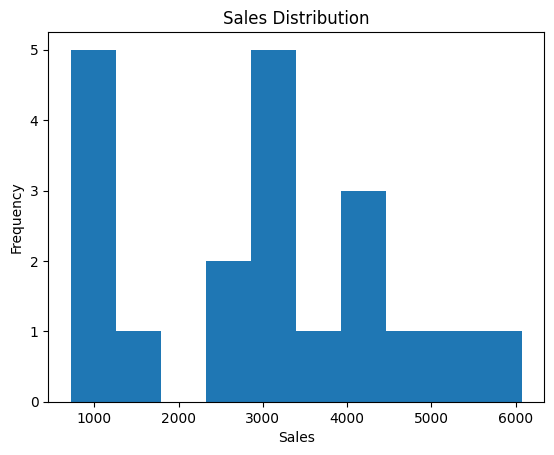

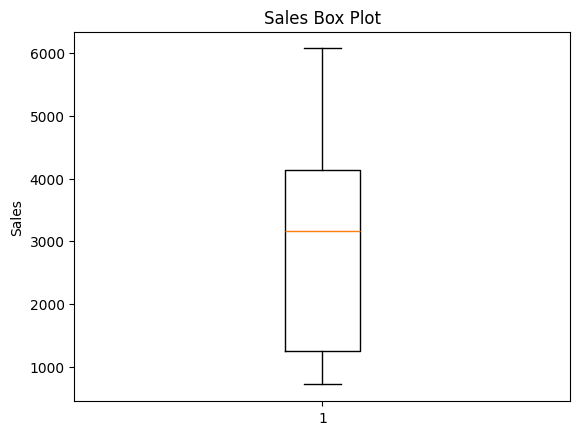


SALES BY CATEGORY
Product_Category
Clothing       16097
Electronics    16713
Furniture      22622
Groceries       3740
Name: Sales, dtype: int64
Highest Sales Category: Furniture


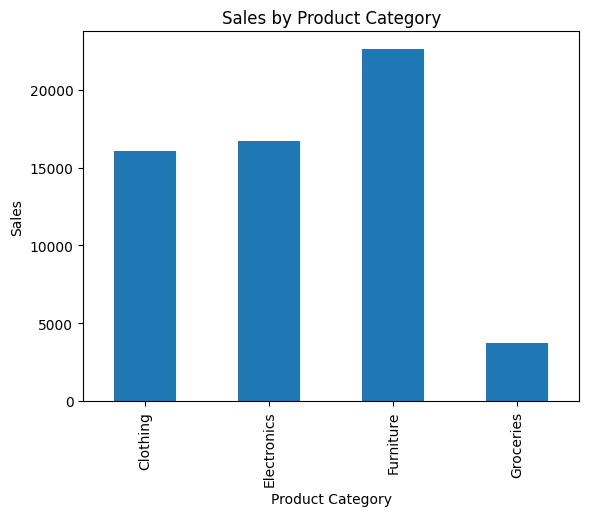

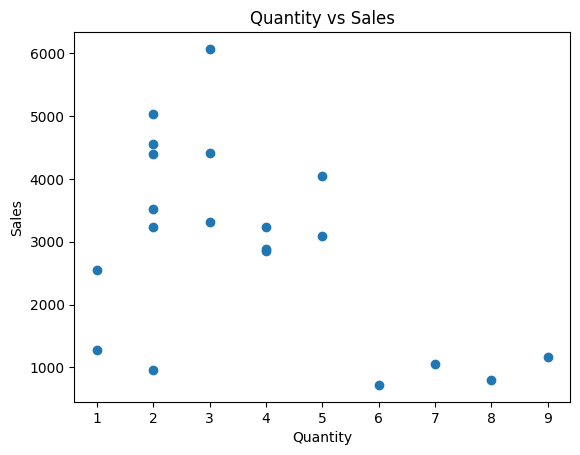

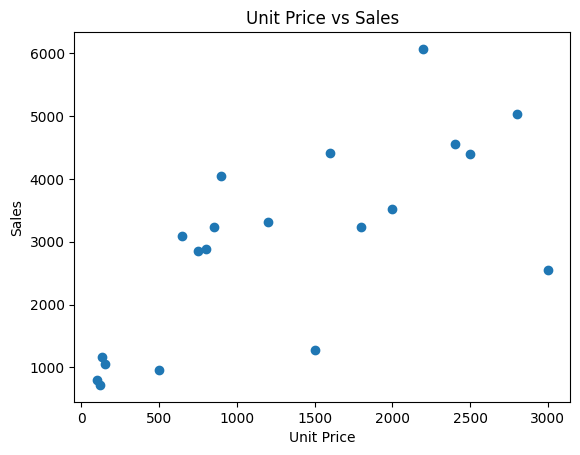

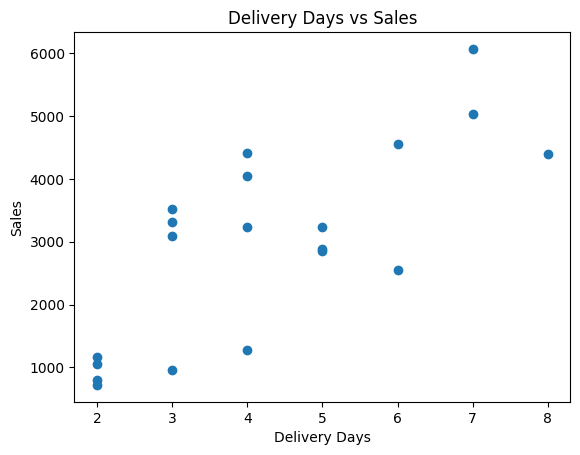


CORRELATION
               Quantity  Unit_Price  Discount  Delivery_Days     Sales
Quantity       1.000000   -0.795071 -0.497068      -0.623873 -0.488171
Unit_Price    -0.795071    1.000000  0.552569       0.801240  0.710890
Discount      -0.497068    0.552569  1.000000       0.555531  0.259886
Delivery_Days -0.623873    0.801240  0.555531       1.000000  0.755337
Sales         -0.488171    0.710890  0.259886       0.755337  1.000000

CORRELATION WITH SALES
Quantity        -0.488171
Unit_Price       0.710890
Discount         0.259886
Delivery_Days    0.755337
Name: Sales, dtype: float64

Strongest Relationship with Sales: Delivery_Days
Relationship: Positive

LINEAR REGRESSION MODEL TRAINED

NEW ORDER
   Customer_Age  Quantity  Unit_Price  Discount  Delivery_Days
0            30         4        1000         5              4

EXPECTED SALES: 2901.3832665836117


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# DATASET

data = {
    "Order_ID": ["ORD001","ORD002","ORD003","ORD004","ORD005","ORD006","ORD007","ORD008","ORD009","ORD010",
                 "ORD011","ORD012","ORD013","ORD014","ORD015","ORD016","ORD017","ORD018","ORD019","ORD020"],

    "Product_Category": ["Electronics","Clothing","Groceries","Electronics","Furniture",
                         "Clothing","Electronics","Groceries","Furniture","Clothing",
                         "Electronics","Furniture","Groceries","Clothing","Electronics",
                         "Furniture","Groceries","Electronics","Clothing","Furniture"],

    "Customer_Age": [25,32,28,41,35,24,29,45,38,27,31,42,26,36,30,48,33,29,40,37],

    "Quantity": [2,4,6,1,3,5,2,8,2,4,3,1,7,5,2,2,9,3,4,2],

    "Unit_Price": [500,800,120,1500,2200,650,1800,100,2500,750,
                   1200,3000,150,900,2000,2800,130,1600,850,2400],

    "Discount": [5,10,0,15,8,5,10,0,12,5,8,15,0,10,5,12,10,0,8,5],

    "Delivery_Days": [3,5,2,4,7,3,4,2,8,5,3,6,2,4,3,7,2,4,5,6],

    "Sales": [950,2880,720,1275,6072,3087,3240,800,4400,2850,
              3312,2550,1050,4050,3520,5040,1170,4416,3230,4560]
}

df = pd.DataFrame(data)

# PART 1 - DATA UNDERSTANDING

print("DATASET")
print(df)

print("\nFIRST 5 RECORDS")
print(df.head())

print("\nLAST 5 RECORDS")
print(df.tail())

print("\nROWS AND COLUMNS")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nNUMERICAL COLUMNS")
print(df.select_dtypes(include=np.number).columns)

print("\nCATEGORICAL COLUMNS")
print(df.select_dtypes(exclude=np.number).columns)

# PART 2 - DATA CLEANING

print("\nMISSING VALUES")
print(df.isnull().sum())
print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())
df = df.dropna()
df = df.drop_duplicates()
print("\nAFTER CLEANING")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# PART 3 - STATISTICS

print("\nSTATISTICS")
print("Average Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())
print("Range of Sales:", df["Sales"].max() - df["Sales"].min())
print("Standard Deviation:", df["Sales"].std())
print("Average Quantity:", df["Quantity"].mean())
print("Average Delivery Days:", df["Delivery_Days"].mean())


# PART 4 - DATA VISUALIZATION

plt.hist(df["Sales"])
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()
plt.boxplot(df["Sales"])
plt.ylabel("Sales")
plt.title("Sales Box Plot")
plt.show()

category_sales = df.groupby("Product_Category")["Sales"].sum()
print("\nSALES BY CATEGORY")
print(category_sales)
print("Highest Sales Category:",category_sales.idxmax())
category_sales.plot(kind="bar")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.title("Sales by Product Category")
plt.show()

plt.scatter(df["Quantity"], df["Sales"])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

plt.scatter(df["Unit_Price"], df["Sales"])
plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.title("Unit Price vs Sales")
plt.show()

plt.scatter(df["Delivery_Days"], df["Sales"])
plt.xlabel("Delivery Days")
plt.ylabel("Sales")
plt.title("Delivery Days vs Sales")
plt.show()

# PART 5 - CORRELATION

print("\nCORRELATION")
correlation = df[
    ["Quantity", "Unit_Price", "Discount",
     "Delivery_Days", "Sales"]
].corr()
print(correlation)
sales_corr = correlation["Sales"].drop("Sales")
print("\nCORRELATION WITH SALES")
print(sales_corr)
strongest = sales_corr.abs().idxmax()
print("\nStrongest Relationship with Sales:",strongest)
relationship = np.where(sales_corr[strongest] > 0, "Positive", "Negative")
print("Relationship:", relationship)


# PART 6 - LINEAR REGRESSION
X = df[
    ["Customer_Age",
     "Quantity",
     "Unit_Price",
     "Discount",
     "Delivery_Days"]
]

y = df["Sales"]
model = LinearRegression()
model.fit(X, y)
print("\nLINEAR REGRESSION MODEL TRAINED")
new_order = pd.DataFrame({
    "Customer_Age": [30],
    "Quantity": [4],
    "Unit_Price": [1000],
    "Discount": [5],
    "Delivery_Days": [4]
})
prediction = model.predict(new_order)
print("\nNEW ORDER")
print(new_order)
print("\nEXPECTED SALES:",prediction[0])